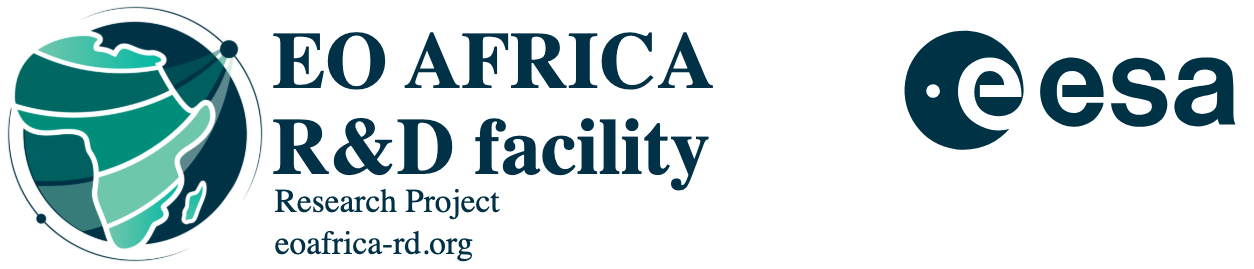

# 06_AQ4ZIM_ZW_NL Workflow 2:
## Compute a TROPOMI dust-smoke-discriminor index (DSDI) and plot it.

In [1]:
#Loading relevant packages
import numpy as np
import glob
import sys
import datetime 
import netCDF4 as nc
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.ndimage import minimum_filter, maximum_filter
import s5p_l1b_class
import geopandas as gpd

This workflow will determine a UV-SWIR Dust Index following the definition for MODIS and VIIRS (https://doi.org/10.1002/2013JD020855), using TROPOMI UV reflectances at 354 nm and TROPOMI SWIR reflectances at 2314 nm:

$\textrm{USDI}_{354,2314} = -10 \cdot ^{{\scriptscriptstyle
1\!0}}\!\log \left(\frac{R_{354}} {R_{2314}}\right)^{\textrm{\scriptsize meas}}$.


In [2]:
#Dynamically select input files, based on date and orbit
tropomi_directory="/home/eoafrica/eodata/Sentinel-5P/TROPOMI/"
#tropomi_directory="data/sentinel-5p/"
#
day=18
month=9
year=2024
orbit=35924
L1B_IR_BD7_product="L1B_IR_SIR"
L1B_IR_BD3_product="L1B_IR_UVN"
L1B_RA_BD3_product="L1B_RA_BD3"
L1B_RA_BD7_product="L1B_RA_BD7"
#
day_file = "{0:04d}/{1:02d}/{2:02d}/*.nc".format(year,month,day)
orbit_file = "{0:04d}/{1:02d}/{2:02d}/*{3}*.nc".format(year,month,day,orbit)
#
L1B_IR_BD3 = glob.glob(tropomi_directory+L1B_IR_BD3_product+"/"+day_file)
L1B_IR_BD7 = glob.glob(tropomi_directory+L1B_IR_BD7_product+"/"+day_file)
L1B_RA_BD3 = glob.glob(tropomi_directory+L1B_RA_BD3_product+"/"+orbit_file)
L1B_RA_BD7 = glob.glob(tropomi_directory+L1B_RA_BD7_product+"/"+orbit_file)
#
#print("L1B_IR_BD3 = '"+L1B_IR_BD3[0]+"'")
#print("L1B_IR_BD7 = '"+L1B_IR_BD7[0]+"'")
#print("L1B_RA_BD3 = '"+L1B_RA_BD3[0]+"'")
#print("L1B_RA_BD7 = '"+L1B_RA_BD7[0]+"'")

In [3]:
#OR manually set the files here:
L1B_IR_BD3 = '/home/eoafrica/eodata/Sentinel-5P/TROPOMI/L1B_IR_UVN/2024/09/18/S5P_OFFL_L1B_IR_UVN_20240918T094004_20240918T112133_35923_03_020100_20240918T130619.nc'
L1B_IR_BD7 = '/home/eoafrica/eodata/Sentinel-5P/TROPOMI/L1B_IR_SIR/2024/09/18/S5P_OFFL_L1B_IR_SIR_20240918T094004_20240918T112133_35923_03_020100_20240918T130619.nc'
L1B_RA_BD3 = '/home/eoafrica/eodata/Sentinel-5P/TROPOMI/L1B_RA_BD3/2024/09/18/S5P_OFFL_L1B_RA_BD3_20240918T112133_20240918T130302_35924_03_020100_20240918T144624.nc'
L1B_RA_BD7 = '/home/eoafrica/eodata/Sentinel-5P/TROPOMI/L1B_RA_BD7/2024/09/18/S5P_OFFL_L1B_RA_BD7_20240918T112133_20240918T130302_35924_03_020100_20240918T144624.nc'

In [4]:
#DEFINE a (small) range of scanlines along the flight direction for reading 
#(None will select the entire orbit)
selected_sl=np.arange(1200,2000)
wav3 =np.array([354.])
wav7 =np.array([2314.])


In [5]:
refl_b3=s5p_l1b_class.s5p_l1b_class(L1B_IR_BD3,L1B_RA_BD3,index=selected_sl,
                   wavelengths=wav3,wavelength_bandwidth=1,band=3,read=1)

2026-03-19 09:49:35 Opening S5P_OFFL_L1B_IR_UVN_20240918T094004_20240918T112133_35923_03_020100_20240918T130619.nc


/home/eoafrica/workflow/s5p_l1b_class.py:187: UserWarning: WARNING: unsupported Compound type, skipping...
  ref = netCDF4.Dataset(irrfile, "r")


2026-03-19 09:49:35 Opening S5P_OFFL_L1B_RA_BD3_20240918T112133_20240918T130302_35924_03_020100_20240918T144624.nc


/home/eoafrica/workflow/s5p_l1b_class.py:107: UserWarning: WARNING: unsupported Compound type, skipping...
  ref = netCDF4.Dataset(radfile, mode = 'r')


In [6]:
refl_b7=s5p_l1b_class.s5p_l1b_class(L1B_IR_BD7,L1B_RA_BD7,index=selected_sl,
                    wavelengths=wav7,wavelength_bandwidth=1,band=7,read=1)


2026-03-19 09:51:49 Opening S5P_OFFL_L1B_IR_SIR_20240918T094004_20240918T112133_35923_03_020100_20240918T130619.nc
2026-03-19 09:51:49 Opening S5P_OFFL_L1B_RA_BD7_20240918T112133_20240918T130302_35924_03_020100_20240918T144624.nc


We have now opened and read TROPOMI reflectances from different bands, which means measurements from different telescopes with different dimensions:

In [ ]:
print(refl_b3.reflectance[:,:,0].shape)
print(refl_b7.reflectance[:,:,0].shape)

In order to divide the two, the SWIR measurements are first regridded to the UV measurement grid:

In [66]:
#Shortwave and UV have different spatial resolution
#Perfoming resampling to on band 7 to match band 3
points = (refl_b7.longitude.flatten(), refl_b7.latitude.flatten())
values = refl_b7.reflectance[:,:,0].flatten()
s5p_r2314 = griddata(points, values, (refl_b3.longitude, refl_b3.latitude), method = 'nearest')

In [67]:
s5p_r354=refl_b3.reflectance[:,:,0]

In [68]:
print(s5p_r354.shape)
print(s5p_r2314.shape)

(800, 450)
(800, 450)


Now we are ready to compute the USDI and plot it over Zimbabwe:

In [69]:
#Tropomi Dust Smoke Discrimination Index (DSDI)
#Determine the UV-SWIR Dust Index from Measured reflectance 354(B3) and 2314(B7) USDI354,2314 = −10 ·10log R354/R2314

tropomi_usdi =(np.log10(s5p_r354/s5p_r2314))*-10
tropomi_lon = refl_b3.longitude
tropomi_lat = refl_b3.latitude

In [83]:
print(cwd+"Africa.geojson")

/home/eoafrica/workflows/Africa.geojson


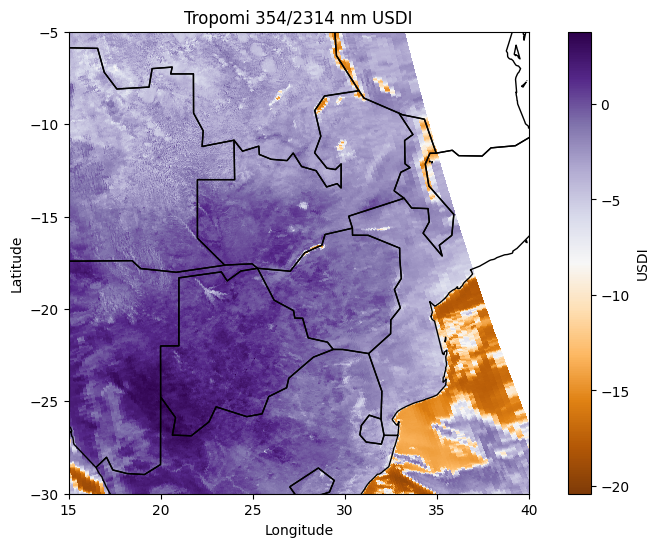

In [84]:
fig, ax = plt.subplots(figsize=(10, 6))
mesh = ax.pcolormesh(tropomi_lon, tropomi_lat, tropomi_usdi, shading='auto', cmap='PuOr')


Zim = gpd.read_file(cwd+"Africa.geojson")
plt.colorbar(mesh, ax=ax, label='USDI')
Zim.boundary.plot(ax=ax, edgecolor='black', linewidth=1)
ax.set_title('Tropomi 354/2314 nm USDI')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
# SET BOUNDARIES
ax.set_xlim([15,40]) # Longitude min/max
ax.set_ylim([-30,-5])    # Latitude min/max
plt.show()